# REINFORCE Tutorial
*Reinforcement Learning (2026), University of Milan*

*Lecturer: Matteo Papini*

In this tutorial we will:
1. Implement a custom **Linear Quadratic Regulator (LQR)** environment using [gymnasium](https://gymnasium.farama.org/index.html) and [numpy](https://numpy.org/)
2. Implement a **linear Gaussian policy** using [pytorch](https://docs.pytorch.org/tutorials/index.html)
3. Implement the **REINFORCE** algorithm

Follow-up exercises:

4. Implement the **variance reduction** techniques seen in class (baselines, GPOMDP)
5. Extend to **multi-dimensional actions**

In [2]:
import gymnasium as gym
from gymnasium import spaces
from gymnasium.envs.registration import register, registry
import numpy as np
import warnings
import torch
import matplotlib.pyplot as plt

## 1. Linear Quadratic Regulator (LQR)

Consider a time-invariant dynamical system with **continuous states and actions**
$$
  \mathcal{S} = \mathbb{R}^{d_{\mathcal{S}}}, \qquad \mathcal{A} = \mathbb{R}^{d_{\mathcal{A}}}
$$
The initial state is sampled from a multivariate standard normal distribution
$$
  s_0 \sim \mathcal{N}(\mathbf{0}, I_{d_{\mathcal{S}}})
$$
where $I_d$ denotes the $d\times d$ identity matrix.

The next state is a **linear** function of the current state and the action plus some centered Gaussian noise:
$$
  s_{t+1} = As_t + Ba_t + \eta_t
$$
where
$$
A \in \mathbb{R}^{d_{\mathcal{S}}\times d_{\mathcal{S}}}, \qquad B \in \mathbb{R}^{d_{\mathcal{S}}\times d_{\mathcal{A}}}, \qquad \eta \sim \mathcal{N}(\mathbf{0}, \sigma_s I_{d_{\mathcal{S}}})
$$
and $\qquad 0<\sigma_s\ll 1$ is a small standard deviation.

Rewards are negative and **quadratic** in the state and the action (quadratic costs):
$$
  r(s_t,a_t) = -s_t^\top Q s_t - a_t^\top R a_t
$$
where
$$
  Q \in \mathbb{R}^{d_{\mathcal{S}}\times d_{\mathcal{S}}}, \qquad R \in \mathbb{R}^{d_{\mathcal{A}}\times d_{\mathcal{A}}}
$$
are symmetric positive definite matrices.

The goal is to bring the state to the origin as quickly as possible, but taking into account the cost of large actions. This system can be used to model or locally approximate many control problems, and is widely used in the optimal control literature.

We will consider a finite-horizon version with epsisodes of fixed length $T$, no discounting, and no terminal costs.

In particular, we will implement the following system with 2-dimensional states and scalar actions:
* $d_{\mathcal{S}} = 2$
* $d_{\mathcal{A}} = 1$
* $\sigma_s = 0.1$
* $A = \begin{bmatrix}
1 & \tfrac{1}{2} \\
\tfrac{1}{2} & 0
\end{bmatrix}$
* $B = [1,0.5]^\top$
* $Q = 0.5I_2$
* $R=0.25$
* $T=10$

We will implement it as a **gym environment** using the gymnasium library, starting from the following template

💡 If you want to try other LQRs, make sure the dimensions are coherent. Moreover, you should avoid *non-controllable* systems. A linear system is controllable is the following $d_{\mathcal{S}}\times d_{\mathcal{S}}d_{\mathcal{A}}$ matrix has rank $d_\mathcal{S}$:
$$
  C = [B, AB, A^2B, \dots A^{d_{\mathcal{S}}-1}B]
$$

The partial implementation of LQR below already includes a snippet of code that throws a warning if the system is non-controllable

In [5]:
# Extend Env
class LQR(gym.Env):
    def __init__(
        self,
        sigma=0.1,
        A=np.array([[1, 0.5], [0.5, 0]], dtype=float),
        B=np.array([1, 0.5], dtype=float),
        Q=0.5 * np.eye(2, dtype=float),
        R=0.25,
    ):

        self.sigma = sigma
        self.A = A
        self.B = B
        self.Q = Q
        self.R = R

        self.ds = A.shape[0]
        self.da = 1

        # Controllability check
        powers = [self.B[..., None]]
        for _ in range(self.ds):
            powers.append(self.A @ powers[-1])
        C = np.concatenate(powers, axis=-1)
        if np.linalg.matrix_rank(C) < self.ds:
            warnings.warn("The system is not controllable!", UserWarning)

        # Observation (state) space
        self.observation_space = spaces.Box(
            low=np.array([-np.inf, -np.inf]),
            high=np.array([np.inf, np.inf]),
            dtype=np.float64,
        )

        # Action space
        self.action_space = spaces.Box(low=-np.inf, high=np.inf, dtype=np.float64)

    def reset(self, seed=None, options=None):
        # Reset the state
        self.rng = np.random.default_rng(seed)

        # Set initial state
        self.state = self.rng.normal(size=self.ds) * 1.0

        return self.state, dict()

    def step(self, action, render=False):
        # Compute reward -sTqs - aTRa
        # Equivalently: reward = - self.state.T @ self.Q @ self.state - action.T * self.R * action
        reward = - np.dot(self.state, self.Q @ self.state) - self.R * action**2

        # Update state As + Ba + noise
        noise = self.rng.normal(size=self.ds) * self.sigma
        self.state = self.A @ self.state + self.B * action + noise 

        terminated = False
        truncated = False

        return self.state, reward.item(), terminated, truncated, dict()

    def render(self, mode="human", close=False):
        print(np.array2string(self.state))


# Register the new Env and set the episode length
env_id = "LQR-v0"
T = 10

if env_id in registry:
    del registry[env_id]
register(
    id=env_id,
    entry_point=LQR,
    max_episode_steps=T,
)

Instantiate the environment and check everything is ok

In [6]:
env = gym.make("LQR-v0")

**Initial state**

Is the state of the desided shape?

Do the values look reasonable?

Do you get a different state each time you call the reset method?

In [7]:
s_0, _ = env.reset()
s_0

array([-1.33099427,  0.54143351])

**State transitions**

Does the state change?

Is the shape still correct? The values still reasonable?

Is the state different at each call of the step method?

In [8]:
a_0 = 0.2
s_1, r_1, _, _, _ = env.step(a_0)
s_1

array([-0.92427506, -0.37302141])

**Reward**

Is the reward a negative scalar?

In [9]:
r_1

-1.0423479928985682

**Episode termination**

Does the step method return a true "truncated" flag after T steps?

In [12]:
truncated = False
t = 0
env.reset()
while not truncated:
  _, _, _, truncated, _ = env.step(action=0)
  t += 1
t, truncated

(10, True)

## 2. Linear Gaussian Policy

Optimal control theory (not covered in this class) shows that **linear policies** (in the state) are optimal for LQR
$$
  \pi_{\mathbb{\theta}}(s) = \mathbb{\theta}^\top s
$$
These are deterministic policies. Since policy gradient methods work with stochastic policies, we add some Gaussian noise
$$
  \pi_{\mathbb{\theta}}(a|s) = \mathcal{N}(\mathbb{\theta}^\top s; \sigma_a^2)
$$
We will later use REINFORCE to learn the optimal $\mathbb{\theta}$. The standard deviation $\sigma_a > 0$ is a hyperparameter. We use $\sigma_a=0.1$ as a default value. We will use $\mathbb{\theta}_0=[0,0]^\top$ as initial parameters.

REINFORCE needs to differentiate the policy w.r.t. its parameters, so we implement the policy using **pytorch** to support automatic differentiation.
The proposed implementation of the policy is stateful (it memorizes policy parameters). We will use CPU.

In [65]:
class LinearGaussianPolicy:

    def __init__(self, sigma=0.1, theta=torch.zeros(2).float(), seed=None):
        self.sigma = sigma
        self.theta = theta.requires_grad_(True)
        self.rng = np.random.default_rng(seed)

    def seed(self, seed):
        self.rng = np.random.default_rng(seed)

    def set_theta(self, theta):
        self.theta = theta.float().requires_grad_(True)

    # Mean action for given state (or batch of states)
    def mu(self, s):
        return s @ self.theta 

    # Logarithm of (unnormalized) probability density function
    # Implement to process batches of states and actions
    def log_pdf(self, states, actions):
        log_pdf = - (self.mu(states) - actions)**2 / (2 * self.sigma**2)
        return log_pdf

    # Action sampling
    def act(self, s):
        noise = self.rng.normal() * self.sigma
        return np.dot(self.theta.detach().numpy(), s) + noise

Instantiate the policy and check everything is ok

**Sampling actions**

Is the action close to zero? (With zero parameters, it should be just noise)

Is it different at every call of the act method?

Do you get both positive and negative actions?

In [66]:
pi = LinearGaussianPolicy()
env = gym.make("LQR-v0")
s, _ = env.reset()
a = pi.act(s)
a

np.float64(-0.04166456699283283)

Change the parameters: do actions change accordingly?

In [67]:
pi.set_theta(10 * torch.ones(2))
a_10 = pi.act(s)
a_10

np.float64(0.5332589202456399)

Try different states: do actions change accordingly?

In [68]:
s_10 = 10 * s
a_100 = pi.act(s_10)
a_100

np.float64(5.69267321995585)

**Computing scores**

Is the log pdf differentiable?

In [69]:
log_pdf = pi.log_pdf(torch.from_numpy(s).float(), a)
log_pdf

tensor(-19.5910, grad_fn=<DivBackward0>)

## 3. REINFORCE

To implement the REINFORCE algorithm, we first need a method to simulate episodes and collect trajectories.

The following implementation collects a batch of trajectories as three separate tensors: states, actions, and rewards.

We will use a default batch size of 100 trajectories.

In [75]:
def collect_batch(env, policy, batch_size=100, seed=None):
    # Good practice: different seeds for different episodes
    # Seed both the env and the policy
    # Becomes important with parallel simulation (that is, simulating episodes in parallel - we need to avoid correlations)
    env_ss, agent_ss = np.random.SeedSequence(seed).spawn(2)
    env_seeds = env_ss.generate_state(batch_size)
    agent_seeds = agent_ss.generate_state(batch_size)

    horizon = env.spec.max_episode_steps
    ds = env.observation_space.shape[0]
    states = torch.zeros(size=(batch_size, horizon, ds)).float()
    actions = torch.zeros(size=(batch_size, horizon)).float()
    rewards = torch.zeros((batch_size, horizon)).float()

    for i in range(batch_size):
        s, _ = env.reset(seed=env_seeds[i])
        policy.seed(seed=agent_seeds[i])

        done = False
        t = 0
        while not done:
            states[i, t, :] = torch.from_numpy(s).float()

            a = policy.act(s)
            actions[i, t] = a

            s, r, terminated, truncated, _ = env.step(a)
            rewards[i, t] = r

            done = terminated or truncated
            t += 1

    return states, actions, rewards

Our implementation of REINFORCE will take an env and a policy and will update the policy parameters for a given number (default 200) of iterations. Quite conservatively, we will use a default batch size of 100 and a step size of $10^{-4}$. Feel free to experiment with other values of the hyperparameters.

In [78]:
def reinforce(env, policy, batch_size=100, step_size=1e-4, iterations=200, seed=None):
    seeds = np.random.SeedSequence(seed).generate_state(iterations)

    performances = []

    for k in range(iterations):
        # Simulation
        with torch.no_grad():
            states, actions, rewards = collect_batch(
                env, policy, batch_size, seed=seeds[k]
            )  # (batch_size, horizon, ds), (batch_size, horizon), (batch_size, horizon)

        # Gradient estimation
        # average return * sum(log_pdf) for each state-action pair
        returns = rewards.sum(dim=1)  # (batch_size)
        log_policy = policy.log_pdf(states, actions)  # (batch_size, horizon)
        objective = (returns * log_policy.sum(dim=1)).mean()  # scalar

        # Policy update        
        # alternatively, use backward() and policy.theta.grad
        grad = torch.autograd.grad(objective, policy.theta)[0] # (ds)
        theta_new = policy.theta + step_size * grad

        policy.set_theta(theta_new)

        performance = returns.mean().item()
        print(
            "Iteration %d\nAverage return %f\nParameters %s\nGradient norm %s\n\n"
            % (
                k,
                performance,
                policy.theta.detach().numpy(),
                torch.linalg.vector_norm(grad).item(),
            )
        )
        performances.append(performance)

    return performances

In [110]:
env = gym.make("LQR-v0")

# A too small sigma leads to very noisy gradient estimates, 
# while a too large sigma leads to very biased gradient estimates 
# (since the policy is too stochastic and does not exploit the current best guess for the optimal parameters)
pi = LinearGaussianPolicy(sigma=1) 

performances = reinforce(env, pi, step_size=1e-4, batch_size=100, iterations=100, seed=2026)

Iteration 0
Average return -168.458633
Parameters [-0.18081279 -0.07774095]
Gradient norm 1968.169677734375


Iteration 1
Average return -38.843922
Parameters [-0.20926504 -0.08956994]
Gradient norm 308.1323547363281


Iteration 2
Average return -28.915377
Parameters [-0.2136657  -0.09186174]
Gradient norm 49.61661148071289


Iteration 3
Average return -27.691137
Parameters [-0.2225074  -0.09529343]
Gradient norm 94.8432388305664


Iteration 4
Average return -28.033564
Parameters [-0.24120598 -0.10269681]
Gradient norm 201.1085662841797


Iteration 5
Average return -22.833748
Parameters [-0.25234804 -0.10707927]
Gradient norm 119.72936248779297


Iteration 6
Average return -25.247568
Parameters [-0.26305735 -0.11194211]
Gradient norm 117.61663818359375


Iteration 7
Average return -23.383656
Parameters [-0.26795724 -0.11460904]
Gradient norm 55.7864990234375


Iteration 8
Average return -21.683985
Parameters [-0.27477264 -0.11727542]
Gradient norm 73.18428039550781


Iteration 9
Averag

Let's plot the **learning curve**

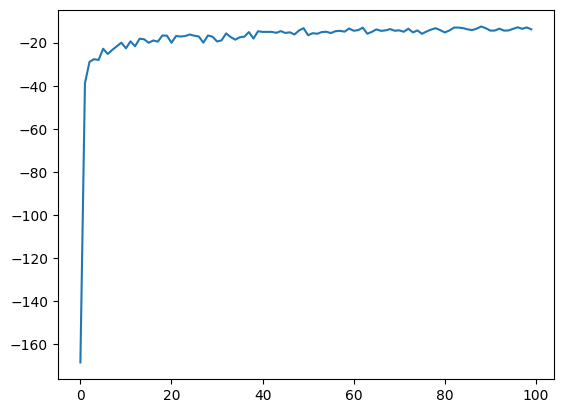

In [111]:
plt.plot(performances)

## 3. Variance Reduction

Try to add an average **baseline** to REINFORCE, and to implement the **GPOMDP** estimator (with and without baseline). Can you observe any improvements in the learning process?

## 4. Multi-Dimensional Actions
Try to solve an LQR with action dimension larger than 1. You will need to make several modifications to the implementation. Most importantly, the policy will be a **multivariate Gaussian**.